# COMP532 Assignment 2 - Problem 1: Lunar Lander with DQN

This notebook implements a Dueling Double DQN agent to solve the LunarLander-v3 environment.

**Key Features:**
- Experience Replay
- Target Network with soft updates
- Double DQN for stable training
- Dueling network architecture
- GPU acceleration when available

In [ ]:
# Import libraries
import csv
import gymnasium as gym
import json
import numpy as np
import shutil
import time
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from pathlib import Path
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

# Set random seeds
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device configuration
FORCE_CPU = True  # Set True to compare CPU runtime with GPU runtime
device = torch.device("cpu" if FORCE_CPU else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

# Always write generated artifacts inside Assignment2.
OUTPUT_DIR = Path.cwd() / "Assignment2" if (Path.cwd() / "Assignment2").exists() else Path.cwd()
RUNS_DIR = OUTPUT_DIR / "run_results"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Run results directory: {RUNS_DIR.resolve()}")

Using device: cuda
Output directory: D:\PythonProject\Git\Assignment2
Run results directory: D:\PythonProject\Git\Assignment2\run_results


In [29]:
class ReplayBuffer:
    """Experience replay buffer."""
    
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

In [30]:
class DuelingDQN(nn.Module):
    """Dueling DQN architecture."""
    
    def __init__(self, state_size, action_size, hidden_size=128):
        super(DuelingDQN, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size)
        )

    def forward(self, state):
        features = self.feature(state)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)
        qvals = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return qvals

In [31]:
class DQNAgent:
    """Dueling Double DQN Agent."""
    
    def __init__(self, state_size, action_size, lr=1e-3, gamma=0.99,
                 tau=0.005, buffer_size=100000, batch_size=64,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.q_network = DuelingDQN(state_size, action_size).to(device)
        self.target_network = DuelingDQN(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer(buffer_size)
        self.losses = []

    def act(self, state, eval_mode=False):
        if not eval_mode and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.q_network(state)
        return q_values.argmax().item()

    def step(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
        if len(self.memory) >= self.batch_size:
            self.learn()

    def learn(self):
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        # Double DQN
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + (1 - dones) * self.gamma * next_q

        current_q = self.q_network(states).gather(1, actions)
        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.losses.append(loss.item())

        # Soft update
        for target_param, param in zip(self.target_network.parameters(), 
                                       self.q_network.parameters()):
            target_param.data.copy_(self.tau * param.data + 
                                   (1 - self.tau) * target_param.data)

        # Epsilon decay
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

In [32]:
def train(env_name="LunarLander-v3", episodes=1000, render_during_training=False):
    # Disable rendering during training for speed; keep rendering only for final GIF export.
    if render_during_training:
        env = gym.make(env_name, render_mode="rgb_array")
    else:
        env = gym.make(env_name)
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size)
    episode_rewards = []
    episode_lengths = []
    all_losses = []

    print(f"\nTraining for {episodes} episodes...")
    print(f"Device: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("=" * 60)

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        step = 0

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            step += 1

        episode_rewards.append(total_reward)
        episode_lengths.append(step)
        all_losses.extend(agent.losses)
        agent.losses = []

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {ep+1}/{episodes}, "
                  f"Avg Reward (last 100): {avg_reward:.2f}, "
                  f"Epsilon: {agent.epsilon:.3f}")

    env.close()
    return agent, episode_rewards, episode_lengths, all_losses

In [33]:
def save_training_results(rewards, losses, lengths, training_seconds, output_root=RUNS_DIR):
    """Persist complete reward/loss series for each run."""
    run_id = time.strftime("%Y%m%d_%H%M%S")
    run_dir = output_root / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    rewards_path = run_dir / "rewards.csv"
    losses_path = run_dir / "losses.csv"
    summary_path = run_dir / "summary.json"
    raw_series_path = run_dir / "raw_series.npz"

    reward_rolling = None
    if len(rewards) >= 50:
        reward_rolling = np.convolve(rewards, np.ones(50) / 50, mode="valid")

    with rewards_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "reward", "rolling_reward_50"])
        for idx, reward in enumerate(rewards, start=1):
            rolling_value = ""
            if reward_rolling is not None and idx >= 50:
                rolling_value = float(reward_rolling[idx - 50])
            writer.writerow([idx, float(reward), rolling_value])

    loss_rolling = None
    if len(losses) >= 100:
        loss_rolling = np.convolve(losses, np.ones(100) / 100, mode="valid")

    with losses_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["update_step", "loss", "rolling_loss_100"])
        for idx, loss in enumerate(losses, start=1):
            rolling_value = ""
            if loss_rolling is not None and idx >= 100:
                rolling_value = float(loss_rolling[idx - 100])
            writer.writerow([idx, float(loss), rolling_value])

    np.savez_compressed(
        raw_series_path,
        rewards=np.asarray(rewards, dtype=np.float32),
        losses=np.asarray(losses, dtype=np.float32),
        episode_lengths=np.asarray(lengths, dtype=np.int32),
    )

    if len(rewards) == 0:
        last_100_avg = 0.0
        avg_reward = 0.0
        max_reward = 0.0
        avg_len = 0.0
    else:
        last_100_avg = float(np.mean(rewards[-100:]))
        avg_reward = float(np.mean(rewards))
        max_reward = float(np.max(rewards))
        avg_len = float(np.mean(lengths)) if len(lengths) > 0 else 0.0

    summary = {
        "run_id": run_id,
        "device": str(device),
        "force_cpu": FORCE_CPU,
        "episodes": len(rewards),
        "updates": len(losses),
        "average_reward": avg_reward,
        "max_reward": max_reward,
        "last_100_avg_reward": last_100_avg,
        "average_episode_length": avg_len,
        "training_seconds": float(training_seconds),
        "artifacts": {
            "rewards_csv": str(rewards_path),
            "losses_csv": str(losses_path),
            "raw_series_npz": str(raw_series_path),
        },
    }

    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(f"Run metrics saved to '{run_dir}'")
    print(f"- Rewards: {rewards_path}")
    print(f"- Losses: {losses_path}")
    print(f"- Summary: {summary_path}")
    print(f"- Raw series: {raw_series_path}")
    return run_dir, summary

In [ ]:
# Train the agent (rendering disabled during training for speed)
train_start = time.time()
agent, rewards, lengths, losses = train(episodes=1000, render_during_training=False)
training_seconds = time.time() - train_start

run_dir, run_summary = save_training_results(
    rewards, losses, lengths, training_seconds=training_seconds
 )
print(f"Training time: {training_seconds/60:.2f} minutes")
print(f"Run folder: {run_dir}")
print(f"Saved last-100 avg reward: {run_summary['last_100_avg_reward']:.2f}")


Training for 1000 episodes...
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [ ]:
# Print summary
print("\n" + "=" * 60)
print("Training Complete!")
print("=" * 60)
print(f"Total Episodes: {len(rewards)}")
print(f"Average Reward: {np.mean(rewards):.2f}")
print(f"Highest Reward: {max(rewards):.2f}")
print(f"Last 100 Episodes Avg Reward: {np.mean(rewards[-100:]):.2f}")
print(f"Average Episode Length: {np.mean(lengths):.1f}")
print(f"Device: {device}")
if device.type == "cuda":
    print("✓ GPU acceleration used")
else:
    print("⚠ CPU used for training")
print("=" * 60)


Training Complete!
Total Episodes: 1000
Average Reward: 166.45
Highest Reward: 318.25
Last 100 Episodes Avg Reward: 160.55
Average Episode Length: 296.7
Device: cpu
⚠ CPU used for training


Training curves saved to 'd:\PythonProject\Git\Assignment2\training_curves.png'


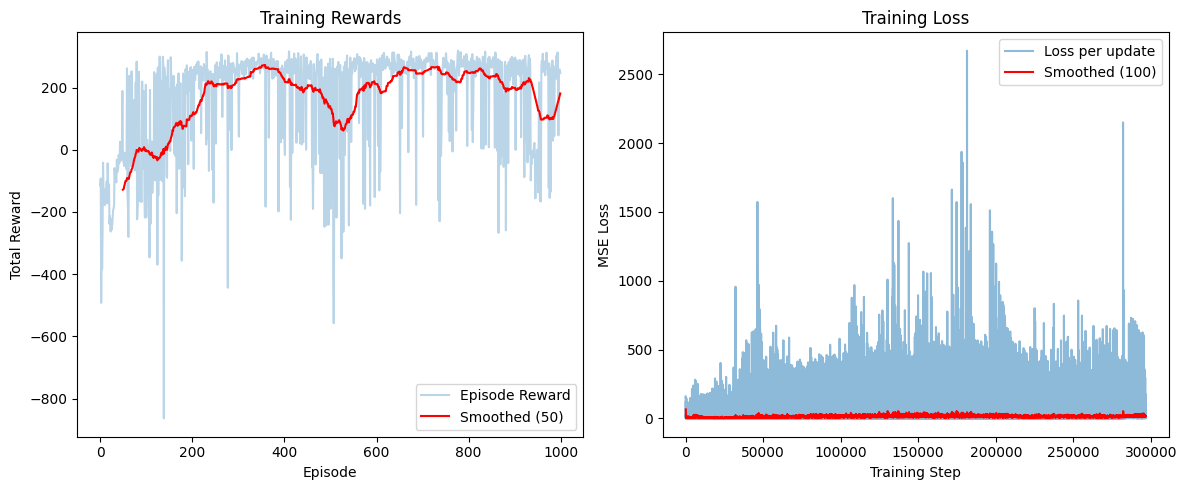

In [ ]:
# Plot results
plt.figure(figsize=(12, 5))

# Rewards
plt.subplot(1, 2, 1)
plt.plot(rewards, alpha=0.3, label='Episode Reward')
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), smoothed, 'r', 
         label=f'Smoothed ({window})')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Training Rewards')
plt.legend()

# Losses
plt.subplot(1, 2, 2)
plt.plot(losses, alpha=0.5, label='Loss per update')
if len(losses) > 100:
    smoothed_loss = np.convolve(losses, np.ones(100)/100, mode='valid')
    plt.plot(range(99, len(losses)), smoothed_loss, 'r', 
             label='Smoothed (100)')
plt.xlabel('Training Step')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.legend()

plt.tight_layout()
curve_path = OUTPUT_DIR / 'training_curves.png'
plt.savefig(curve_path, dpi=150)
print(f"Training curves saved to '{curve_path}'")

if 'run_dir' in globals():
    run_curve_path = run_dir / 'training_curves.png'
    if run_curve_path != curve_path:
        shutil.copy2(curve_path, run_curve_path)
        print(f"Run-specific curve copy saved to '{run_curve_path}'")

plt.show()

GIF saved to 'd:\PythonProject\Git\Assignment2\lander_final.gif'


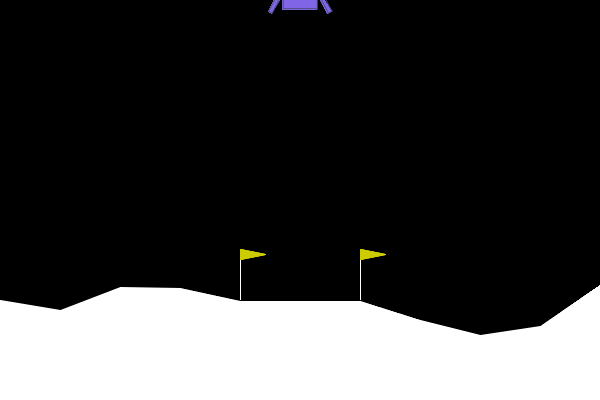

In [ ]:
# Record final episode
def record_episode(agent, env_name="LunarLander-v3", gif_path=None):
    env = gym.make(env_name, render_mode="rgb_array")
    frames = []
    state, _ = env.reset()
    done = False

    if gif_path is None:
        gif_path = OUTPUT_DIR / "lander_final.gif"
    else:
        gif_path = Path(gif_path)
        if not gif_path.is_absolute():
            gif_path = OUTPUT_DIR / gif_path
    
    while not done:
        frames.append(env.render())
        action = agent.act(state, eval_mode=True)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
    env.close()
    imageio.mimsave(str(gif_path), frames, fps=30)
    print(f"GIF saved to '{gif_path}'")
    return gif_path

gif_file = record_episode(agent)

if 'run_dir' in globals():
    run_gif_path = run_dir / 'lander_final.gif'
    if run_gif_path != gif_file:
        shutil.copy2(gif_file, run_gif_path)
        print(f"Run-specific GIF copy saved to '{run_gif_path}'")

# Display in notebook
Image(open(gif_file, 'rb').read())